# Integración de patentes y exclusividades regulatorias

## Objetivo 

El objetivo de este notebook es enriquecer la base analítica preliminar construida en el notebook anterior con información de patentes y exclusividades regulatorias provenientes del Orange Book.

En el notebook `01_ingesta_orangebook_drugsfda.ipynb` se realizó la primera fase del proyecto:

1. lectura de archivos de Orange Book y Drugs@FDA;
2. normalización de llaves;
3. separación preliminar de productos NDA y ANDA;
4. construcción de unidades ingrediente--forma--ruta;
5. identificación preliminar del primer genérico comparable;
6. construcción de la base `survival_analysis_v1`;
7. estimación de una primera curva Kaplan--Meier global.

En este segundo notebook se busca avanzar hacia una base más explicativa, incorporando variables regulatorias y de protección comercial.



## Motivación

El tiempo hasta la entrada de genéricos no depende únicamente de la fecha de aprobación del medicamento innovador. También puede estar influido por:

- patentes listadas en Orange Book;
- fechas de expiración de patentes;
- patentes de sustancia activa;
- patentes de producto farmacéutico;
- patentes de uso;
- exclusividades regulatorias;
- duración de la protección regulatoria;
- diferencias entre productos con o sin exclusividad vigente.

Por ello, el siguiente paso consiste en agregar estas variables al dataset de supervivencia.


## Fuentes utilizadas en este notebook

Se utilizarán principalmente tres archivos generados o leídos previamente.

### 1. Base analítica preliminar

Archivo: *data_intermediate/survival_analysis_v1.parquet*


Esta base contiene una fila por unidad preliminar ingrediente--forma--ruta e incluye:

- fecha de aprobación del innovador candidato;
- fecha del primer genérico comparable;
- indicador de evento;
- tiempo hasta genérico o censura;
- aplicación NDA del innovador;
- producto NDA del innovador;
- aplicación ANDA del primer genérico, cuando existe.

### 2. Archivo de patentes de Orange Book

Archivo: *orange_book/patent.txt*

Este archivo contiene información de patentes asociadas a aplicaciones y productos. Entre sus variables se encuentran:

- número de aplicación;
- número de producto;
- número de patente;
- fecha de expiración de patente;
- indicador de patente de sustancia;
- indicador de patente de producto;
- código de uso de patente;
- indicador de delisting.

Estas variables permitirán construir indicadores como:

- número de patentes asociadas al innovador;
- fecha mínima de expiración de patente;
- fecha máxima de expiración de patente;
- presencia de patente de sustancia;
- presencia de patente de producto;
- presencia de patente de uso.

### 3. Archivo de exclusividades de Orange Book

Archivo: *orange_book/exclusivity.txt*

Este archivo contiene códigos de exclusividad regulatoria y fechas de expiración. Permitirá construir variables como:

- número de exclusividades;
- fecha máxima de expiración de exclusividad;
- presencia de códigos específicos de exclusividad;
- tiempo desde aprobación hasta expiración de exclusividad.

## Unidad de integración

La integración se realizará inicialmente usando las llaves del innovador:

innovator_appl_no
innovator_product_no

Estas llaves se vincularán con:

appl_no
product_no

en las tablas de patentes y exclusividades.

Esta integración trabaja a nivel producto. Es una primera aproximación práctica, porque cada unidad ingrediente--forma--ruta en la base analítica conserva la aplicación y el producto NDA que representan la primera aprobación observada.


## Salidas esperadas

Al final del notebook se espera generar una base enriquecida:

data_intermediate/survival_analysis_v2_patents_exclusivities.parquet

data_intermediate/survival_analysis_v2_patents_exclusivities.csv

Esta base contendrá las variables necesarias para comparar curvas de supervivencia por subgrupos y, posteriormente, ajustar modelos Cox o AFT.

# Preguntas descriptivas iniciales

Con la base enriquecida se buscará responder preguntas como:

- ¿Los productos con patentes listadas tardan más en tener genéricos?
- ¿La fecha máxima de expiración de patente se asocia con mayor tiempo hasta genérico?
- ¿Los productos con exclusividades regulatorias muestran curvas Kaplan--Meier distintas?
- ¿Qué proporción de productos tiene patentes de sustancia, producto o uso?
- ¿Qué tipos de exclusividad aparecen con mayor frecuencia en la cohorte?

## 1. Preparación del entorno y carga de archivos

En esta primera celda se cargan las librerías necesarias, se definen las rutas principales del proyecto y se leen tres fuentes de información:

1. la base analítica preliminar `survival_analysis_v1.parquet`;
2. el archivo de patentes `patent.txt`;
3. el archivo de exclusividades `exclusivity.txt`.

También se volverán a definir funciones auxiliares para normalizar nombres de columnas y llaves (`appl_no`, `product_no`), de manera que este notebook pueda ejecutarse de forma independiente del notebook anterior.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


# Rutas principales


PROJECT_DIR = Path.cwd()

ORANGE_BOOK_DIR = PROJECT_DIR / "orange_book"
DATA_INTERMEDIATE_DIR = PROJECT_DIR / "data_intermediate"
DATA_FINAL_DIR = PROJECT_DIR / "data_final"
FIGURES_DIR = PROJECT_DIR / "figures"
TABLES_DIR = PROJECT_DIR / "tables"

for folder in [DATA_INTERMEDIATE_DIR, DATA_FINAL_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(exist_ok=True)


# Funciones auxiliares


def clean_column_name(col):
    """
    Convierte nombres de columnas a formato snake_case sencillo.
    """
    col = col.strip()
    col = col.replace(";", "_")
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    return col.lower()


def standardize_columns(df):
    """
    Estandariza nombres de columnas.
    """
    out = df.copy()
    out.columns = [clean_column_name(c) for c in out.columns]
    return out


def normalize_appl_no(x):
    """
    Normaliza número de aplicación FDA a texto de 6 dígitos.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\.0$", "", x)
    x = re.sub(r"\D", "", x)
    if x == "":
        return np.nan
    return x.zfill(6)


def normalize_product_no(x):
    """
    Normaliza número de producto FDA a texto de 3 dígitos.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\.0$", "", x)
    x = re.sub(r"\D", "", x)
    if x == "":
        return np.nan
    return x.zfill(3)


def read_text_table(path, sep, encoding="latin1"):
    """
    Lee una tabla de texto conservando columnas como texto.
    """
    return pd.read_csv(
        path,
        sep=sep,
        dtype=str,
        encoding=encoding,
        low_memory=False
    )



# Cargar base analítica preliminar


survival_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v1.parquet"

survival_v1 = pd.read_parquet(survival_path)


# Cargar archivos de Orange Book


ob_patent = read_text_table(ORANGE_BOOK_DIR / "patent.txt", sep="~")
ob_exclusivity = read_text_table(ORANGE_BOOK_DIR / "exclusivity.txt", sep="~")

ob_patent = standardize_columns(ob_patent)
ob_exclusivity = standardize_columns(ob_exclusivity)

# Normalizar llaves
for df in [ob_patent, ob_exclusivity]:
    df["appl_no"] = df["appl_no"].apply(normalize_appl_no)
    df["product_no"] = df["product_no"].apply(normalize_product_no)

print("=" * 80)
print("Archivos cargados correctamente")
print("=" * 80)

print(f"survival_v1:     {survival_v1.shape[0]:,} filas | {survival_v1.shape[1]:,} columnas")
print(f"ob_patent:       {ob_patent.shape[0]:,} filas | {ob_patent.shape[1]:,} columnas")
print(f"ob_exclusivity:  {ob_exclusivity.shape[0]:,} filas | {ob_exclusivity.shape[1]:,} columnas")

print("\nColumnas de survival_v1:")
print(list(survival_v1.columns))

print("\nColumnas de ob_patent:")
print(list(ob_patent.columns))

print("\nColumnas de ob_exclusivity:")
print(list(ob_exclusivity.columns))

Archivos cargados correctamente
survival_v1:     1,439 filas | 23 columnas
ob_patent:       20,858 filas | 10 columnas
ob_exclusivity:  2,054 filas | 5 columnas

Columnas de survival_v1:
['ingredient', 'dosage_form', 'route', 'nme_approval_date', 'approval_year', 'innovator_appl_no', 'innovator_product_no', 'innovator_trade_name', 'first_generic_approval_date', 'first_generic_appl_no', 'first_generic_product_no', 'first_generic_trade_name', 'first_generic_te_code', 'event', 'end_date', 'time_to_generic_years', 'n_nda_products', 'n_nda_applications', 'n_anda_products_total', 'n_anda_applications_total', 'ingredient_key', 'dosage_form_key', 'route_key']

Columnas de ob_patent:
['appl_type', 'appl_no', 'product_no', 'patent_no', 'patent_expire_date_text', 'drug_substance_flag', 'drug_product_flag', 'patent_use_code', 'delist_flag', 'submission_date']

Columnas de ob_exclusivity:
['appl_type', 'appl_no', 'product_no', 'exclusivity_code', 'exclusivity_date']


Los archivos necesarios para el segundo notebook se cargaron correctamente.

La base `survival_v1` contiene 1,439 filas y 23 columnas. Esta es la base analítica preliminar generada en el notebook anterior, con una fila por unidad ingrediente--forma--ruta y las variables principales del endpoint de supervivencia.

También se cargaron correctamente las dos tablas regulatorias principales del Orange Book:

- `ob_patent`: 20,858 registros de patentes;
- `ob_exclusivity`: 2,054 registros de exclusividades.

La tabla `ob_patent` contiene las variables necesarias para construir indicadores de protección por patente, tales como número de patentes, fechas de expiración, patentes de sustancia, patentes de producto y patentes de uso.

La tabla `ob_exclusivity` contiene códigos y fechas de expiración de exclusividades regulatorias. Esta tabla permitirá identificar si el producto innovador tiene exclusividades listadas y cuál es la última fecha de expiración de exclusividad.

La llave que permitirá integrar estas tablas con `survival_v1` será:

- `innovator_appl_no` con `appl_no`;
- `innovator_product_no` con `product_no`.


## 2. Limpieza y revisión de fechas de patentes y exclusividades

Antes de integrar patentes y exclusividades con la base de supervivencia, es necesario convertir las fechas de expiración a formato fecha.

En la tabla de patentes, la fecha aparece en la columna:

- `patent_expire_date_text`

En la tabla de exclusividades, la fecha aparece en:

- `exclusivity_date`

La siguiente celda hará lo siguiente:

1. convertir ambas columnas a formato `datetime`;
2. contar cuántas fechas se pudieron convertir;
3. revisar el rango temporal de expiraciones;
4. mostrar ejemplos de fechas problemáticas, si existen.

Esta revisión es importante porque las fechas de expiración se usarán para construir variables como:

- fecha mínima de expiración de patente;
- fecha máxima de expiración de patente;
- años desde aprobación hasta expiración máxima de patente;
- fecha máxima de expiración de exclusividad;
- años desde aprobación hasta expiración máxima de exclusividad.

In [4]:
ob_patent = ob_patent.copy()
ob_exclusivity = ob_exclusivity.copy()

# Convertir fechas
ob_patent["patent_expire_date"] = pd.to_datetime(
    ob_patent["patent_expire_date_text"],
    errors="coerce"
)

ob_patent["submission_date_parsed"] = pd.to_datetime(
    ob_patent["submission_date"],
    errors="coerce"
)

ob_exclusivity["exclusivity_date_parsed"] = pd.to_datetime(
    ob_exclusivity["exclusivity_date"],
    errors="coerce"
)

print("=" * 80)
print("Patentes: conversión de fechas")
print("=" * 80)

print(f"Registros totales: {len(ob_patent):,}")
print(f"Fechas de expiración convertidas: {ob_patent['patent_expire_date'].notna().sum():,}")
print(f"Fechas de expiración no convertidas: {ob_patent['patent_expire_date'].isna().sum():,}")

print("\nRango de expiración de patentes:")
print("Mínima:", ob_patent["patent_expire_date"].min())
print("Máxima:", ob_patent["patent_expire_date"].max())

print("\nFechas de patente no convertidas más frecuentes:")
print(
    ob_patent.loc[
        ob_patent["patent_expire_date"].isna(),
        "patent_expire_date_text"
    ]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("patent_expire_date_text")
    .reset_index(name="n")
)


print("\n" + "=" * 80)
print("Exclusividades: conversión de fechas")
print("=" * 80)

print(f"Registros totales: {len(ob_exclusivity):,}")
print(f"Fechas de exclusividad convertidas: {ob_exclusivity['exclusivity_date_parsed'].notna().sum():,}")
print(f"Fechas de exclusividad no convertidas: {ob_exclusivity['exclusivity_date_parsed'].isna().sum():,}")

print("\nRango de expiración de exclusividades:")
print("Mínima:", ob_exclusivity["exclusivity_date_parsed"].min())
print("Máxima:", ob_exclusivity["exclusivity_date_parsed"].max())

print("\nFechas de exclusividad no convertidas más frecuentes:")
print(
    ob_exclusivity.loc[
        ob_exclusivity["exclusivity_date_parsed"].isna(),
        "exclusivity_date"
    ]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("exclusivity_date")
    .reset_index(name="n")
)

Patentes: conversión de fechas
Registros totales: 20,858
Fechas de expiración convertidas: 20,858
Fechas de expiración no convertidas: 0

Rango de expiración de patentes:
Mínima: 2025-07-13 00:00:00
Máxima: 2045-07-23 00:00:00

Fechas de patente no convertidas más frecuentes:
Empty DataFrame
Columns: [patent_expire_date_text, n]
Index: []

Exclusividades: conversión de fechas
Registros totales: 2,054
Fechas de exclusividad convertidas: 2,054
Fechas de exclusividad no convertidas: 0

Rango de expiración de exclusividades:
Mínima: 2022-03-06 00:00:00
Máxima: 2035-12-12 00:00:00

Fechas de exclusividad no convertidas más frecuentes:
Empty DataFrame
Columns: [exclusivity_date, n]
Index: []


La conversión de fechas fue exitosa.

En la tabla de patentes, los 20,858 registros tienen una fecha de expiración válida. No se detectaron fechas faltantes ni valores problemáticos. El rango de expiración de patentes va de 2025-07-13 a 2045-07-23.

En la tabla de exclusividades, los 2,054 registros también tienen una fecha de expiración válida. El rango de expiración de exclusividades va de 2022-03-06 a 2035-12-12.

Este resultado es importante porque confirma que las variables temporales de protección regulatoria se pueden usar directamente para enriquecer la base analítica.

Una observación relevante es que las fechas de expiración disponibles en estos archivos corresponden al estado actual del Orange Book descargado. Por tanto, representan patentes y exclusividades actualmente listadas o vigentes en la versión de los datos utilizada, no necesariamente el historial completo de todas las patentes y exclusividades que pudieron haber existido en años anteriores.

El siguiente paso será resumir la información de patentes por aplicación y producto innovador.

## 3. Agregación de información de patentes por producto

La tabla `ob_patent` puede contener múltiples registros para una misma combinación de aplicación y producto. Esto ocurre porque un producto puede tener varias patentes listadas, por ejemplo patentes de sustancia activa, de producto farmacéutico, de formulación o de uso.

Para integrar esta información con la base de supervivencia, necesitamos resumir las patentes a nivel:

appl_no + product_no

En la siguiente celda se construirán variables agregadas como:

- n_patents: número de patentes listadas;
- patent_expiry_min: fecha mínima de expiración de patente;
- patent_expiry_max: fecha máxima de expiración de patente;
- has_drug_substance_patent: indicador de al menos una patente de sustancia;
- has_drug_product_patent: indicador de al menos una patente de producto;
- has_patent_use_code: indicador de al menos un código de uso de patente;
- has_delist_flag: indicador de al menos una patente con solicitud de delisting.

Estas variables permitirán estudiar si la presencia y duración de patentes se asocia con el tiempo hasta la entrada de genéricos.

In [7]:
patent_product_summary = (
    ob_patent
    .groupby(["appl_no", "product_no"], dropna=False)
    .agg(
        n_patents=("patent_no", "nunique"),
        n_patent_records=("patent_no", "size"),
        patent_expiry_min=("patent_expire_date", "min"),
        patent_expiry_max=("patent_expire_date", "max"),
        has_drug_substance_patent=("drug_substance_flag", lambda x: x.astype(str).str.upper().eq("Y").any()),
        has_drug_product_patent=("drug_product_flag", lambda x: x.astype(str).str.upper().eq("Y").any()),
        has_patent_use_code=("patent_use_code", lambda x: x.notna().any()),
        has_delist_flag=("delist_flag", lambda x: x.astype(str).str.upper().eq("Y").any()),
        patent_use_codes=("patent_use_code", lambda x: "; ".join(sorted(x.dropna().astype(str).unique()))),
        patent_numbers=("patent_no", lambda x: "; ".join(sorted(x.dropna().astype(str).unique())))
    )
    .reset_index()
)

# Indicador general
patent_product_summary["has_patent"] = patent_product_summary["n_patents"] > 0

print("=" * 80)
print("Resumen de patentes por appl_no + product_no")
print("=" * 80)

print(f"Filas en resumen de patentes: {len(patent_product_summary):,}")
print(f"Aplicaciones únicas con patentes: {patent_product_summary['appl_no'].nunique():,}")
print(f"Productos únicos con patentes: {patent_product_summary[['appl_no', 'product_no']].drop_duplicates().shape[0]:,}")

print("\nResumen numérico de número de patentes por producto:")
display(
    patent_product_summary["n_patents"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .to_frame(name="n_patents")
)

print("\nDistribución de indicadores de patente:")
patent_flags_summary = pd.DataFrame({
    "variable": [
        "has_drug_substance_patent",
        "has_drug_product_patent",
        "has_patent_use_code",
        "has_delist_flag"
    ],
    "n_true": [
        patent_product_summary["has_drug_substance_patent"].sum(),
        patent_product_summary["has_drug_product_patent"].sum(),
        patent_product_summary["has_patent_use_code"].sum(),
        patent_product_summary["has_delist_flag"].sum()
    ]
})

patent_flags_summary["percent_true"] = (
    100 * patent_flags_summary["n_true"] / len(patent_product_summary)
)

display(patent_flags_summary)

print("\nEjemplos de productos con patentes:")
display(
    patent_product_summary
    .sort_values("n_patents", ascending=False)
    .head(20)
)

Resumen de patentes por appl_no + product_no
Filas en resumen de patentes: 2,588
Aplicaciones únicas con patentes: 1,309
Productos únicos con patentes: 2,588

Resumen numérico de número de patentes por producto:


,n_patents
count,2588.000000
mean,6.462133
std,7.755275
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
90%,14.000000
95%,20.000000
max,130.000000



Distribución de indicadores de patente:


,variable,n_true,percent_true
0,has_drug_substance_patent,1182,45.672334
1,has_drug_product_patent,2278,88.021638
2,has_patent_use_code,2050,79.211747
3,has_delist_flag,45,1.738794



Ejemplos de productos con patentes:


,appl_no,product_no,n_patents,n_patent_records,patent_expiry_min,patent_expiry_max,has_drug_substance_patent,has_drug_product_patent,has_patent_use_code,has_delist_flag,patent_use_codes,patent_numbers,has_patent
2128,215430,001,130,130,2033-10-29,2043-04-20,False,True,True,False,U-3419; U-3563; U-3778,10058518; 10064857; 10080727; 10092560; 100925...,True
2129,215431,001,82,82,2036-04-11,2045-03-10,False,True,True,False,U-1719; U-4133; U-4134; U-4135; U-4136; U-4356,10029010; 10058614; 10137131; 10195278; 102653...,True
1544,210563,004,70,110,2026-12-28,2036-09-03,True,True,True,False,U-1456; U-1491; U-1650; U-1684; U-1946; U-1947...,10004746; 10004746*PED; 10010507; 10010507*PED...,True
1541,210563,001,68,106,2026-12-28,2036-09-03,True,True,True,False,U-1491; U-1650; U-1684; U-1946; U-2159; U-2241...,10004746; 10004746*PED; 10010507; 10010507*PED...,True
939,205552,001,67,99,2026-12-28,2035-04-24,True,True,True,False,U-1491; U-1650; U-1683; U-1684; U-1745; U-1946...,10004746; 10004746*PED; 10016435; 10016435*PED...,True
1543,210563,003,66,104,2026-12-28,2036-09-03,True,True,True,False,U-1491; U-1650; U-1684; U-1946; U-2159; U-2241...,10004746; 10004746*PED; 10010507; 10010507*PED...,True
1542,210563,002,66,104,2026-12-28,2036-09-03,True,True,True,False,U-1491; U-1650; U-1684; U-1946; U-2159; U-2241...,10004746; 10004746*PED; 10010507; 10010507*PED...,True
940,205552,002,65,97,2026-12-28,2035-04-24,True,True,True,False,U-1491; U-1650; U-1684; U-1946; U-2159; U-2219...,10004746; 10004746*PED; 10016435; 10016435*PED...,True
1305,208623,001,63,64,2027-05-16,2042-01-11,True,False,True,True,U-2371; U-2372; U-2373,10076514; 10251873; 10383864; 10406143; 104710...,True
585,202057,001,62,65,2027-05-31,2033-06-28,False,True,True,False,U-1287; U-1478; U-2688; U-2689; U-2690; U-2691...,10010517; 10265287; 10278935; 10278936; 102789...,True


La agregación de patentes por combinación `appl_no + product_no` se realizó correctamente.

A partir de los 20,858 registros originales de patentes, se obtuvieron 2,588 productos únicos con al menos una patente listada. Estos productos corresponden a 1,309 aplicaciones únicas.

El número de patentes por producto presenta una distribución heterogénea:

- mínimo: 1 patente;
- mediana: 4 patentes;
- percentil 75: 8 patentes;
- percentil 90: 14 patentes;
- máximo: 130 patentes.

Esto indica que algunos productos tienen carteras de patentes muy extensas. Estos casos pueden corresponder a productos recientes, productos con múltiples indicaciones, formulaciones complejas o estrategias de protección acumulada.

En cuanto a los indicadores de tipo de patente, se observa que:

- 45.7% de los productos con patentes tienen al menos una patente de sustancia;
- 88.0% tienen al menos una patente de producto;
- 79.2% tienen al menos un código de uso de patente;
- 1.7% tienen al menos una patente con indicador de delisting.

Estos indicadores serán útiles para comparar curvas de supervivencia y, posteriormente, construir modelos de riesgo. Por ejemplo, podremos evaluar si la presencia de patente de sustancia o una fecha máxima de expiración más lejana se asocia con mayor tiempo hasta la entrada de genéricos.

También es importante notar que las fechas de expiración de patentes disponibles corresponden a la versión actual del Orange Book. Por ello, estas variables representan la cartera de patentes observada al momento de descarga, no necesariamente el historial completo de patentes desde la aprobación original.

## 4. Agregación de exclusividades por producto

De forma análoga a las patentes, una misma combinación `appl_no + product_no` puede tener una o varias exclusividades regulatorias listadas.

En esta celda se resumirá la tabla `ob_exclusivity` a nivel producto, construyendo variables como:

- `n_exclusivities`: número de códigos de exclusividad distintos;
- `exclusivity_expiry_min`: primera fecha de expiración de exclusividad;
- `exclusivity_expiry_max`: última fecha de expiración de exclusividad;
- `exclusivity_codes`: lista de códigos de exclusividad observados;
- `has_exclusivity`: indicador general de presencia de exclusividad.

Además, se crearán indicadores preliminares para algunos tipos de exclusividad a partir de los códigos disponibles. Esta clasificación inicial es exploratoria, ya que los códigos de exclusividad del Orange Book pueden incluir múltiples categorías y subcategorías.

In [9]:
exclusivity_product_summary = (
    ob_exclusivity
    .groupby(["appl_no", "product_no"], dropna=False)
    .agg(
        n_exclusivities=("exclusivity_code", "nunique"),
        n_exclusivity_records=("exclusivity_code", "size"),
        exclusivity_expiry_min=("exclusivity_date_parsed", "min"),
        exclusivity_expiry_max=("exclusivity_date_parsed", "max"),
        exclusivity_codes=("exclusivity_code", lambda x: "; ".join(sorted(x.dropna().astype(str).unique())))
    )
    .reset_index()
)

exclusivity_product_summary["has_exclusivity"] = exclusivity_product_summary["n_exclusivities"] > 0

# Indicadores exploratorios por patrones frecuentes de códigos.
# Estos patrones se revisarán más adelante con el diccionario oficial.
exclusivity_product_summary["has_nce_like_exclusivity"] = (
    exclusivity_product_summary["exclusivity_codes"]
    .astype(str)
    .str.contains(r"\bNCE\b", case=False, regex=True)
)

exclusivity_product_summary["has_orphan_like_exclusivity"] = (
    exclusivity_product_summary["exclusivity_codes"]
    .astype(str)
    .str.contains(r"\bODE\b|\bORPHAN\b", case=False, regex=True)
)

exclusivity_product_summary["has_pediatric_like_exclusivity"] = (
    exclusivity_product_summary["exclusivity_codes"]
    .astype(str)
    .str.contains(r"\*PED|\bPED\b", case=False, regex=True)
)

print("=" * 80)
print("Resumen de exclusividades por appl_no + product_no")
print("=" * 80)

print(f"Filas en resumen de exclusividades: {len(exclusivity_product_summary):,}")
print(f"Aplicaciones únicas con exclusividades: {exclusivity_product_summary['appl_no'].nunique():,}")
print(f"Productos únicos con exclusividades: {exclusivity_product_summary[['appl_no', 'product_no']].drop_duplicates().shape[0]:,}")

print("\nResumen numérico de número de exclusividades por producto:")
display(
    exclusivity_product_summary["n_exclusivities"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .to_frame(name="n_exclusivities")
)

print("\nCódigos de exclusividad más frecuentes en registros originales:")
display(
    ob_exclusivity["exclusivity_code"]
    .value_counts()
    .head(30)
    .rename_axis("exclusivity_code")
    .reset_index(name="n_records")
)

print("\nIndicadores exploratorios de exclusividad:")
excl_flags_summary = pd.DataFrame({
    "variable": [
        "has_nce_like_exclusivity",
        "has_orphan_like_exclusivity",
        "has_pediatric_like_exclusivity"
    ],
    "n_true": [
        exclusivity_product_summary["has_nce_like_exclusivity"].sum(),
        exclusivity_product_summary["has_orphan_like_exclusivity"].sum(),
        exclusivity_product_summary["has_pediatric_like_exclusivity"].sum()
    ]
})

excl_flags_summary["percent_true"] = (
    100 * excl_flags_summary["n_true"] / len(exclusivity_product_summary)
)

display(excl_flags_summary)

print("\nEjemplos de productos con exclusividades:")
display(
    exclusivity_product_summary
    .sort_values(["n_exclusivities", "exclusivity_expiry_max"], ascending=[False, False])
    .head(20)
)

Resumen de exclusividades por appl_no + product_no
Filas en resumen de exclusividades: 1,035
Aplicaciones únicas con exclusividades: 552
Productos únicos con exclusividades: 1,035

Resumen numérico de número de exclusividades por producto:


,n_exclusivities
count,1035.000000
mean,1.794203
std,1.138888
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
90%,3.000000
95%,4.000000
max,12.000000



Códigos de exclusividad más frecuentes en registros originales:


,exclusivity_code,n_records
0,NCE,362
1,PED,318
2,NPP,131
3,NP,128
4,ODE*,83
5,GAIN,42
6,M-14,41
7,CGT,30
8,M-82,14
9,I-958,12



Indicadores exploratorios de exclusividad:


,variable,n_true,percent_true
0,has_nce_like_exclusivity,363,35.072464
1,has_orphan_like_exclusivity,411,39.710145
2,has_pediatric_like_exclusivity,171,16.521739



Ejemplos de productos con exclusividades:


,appl_no,product_no,n_exclusivities,n_exclusivity_records,exclusivity_expiry_min,exclusivity_expiry_max,exclusivity_codes,has_exclusivity,has_nce_like_exclusivity,has_orphan_like_exclusivity,has_pediatric_like_exclusivity
496,213246,001,12,22,2027-05-08,2031-11-29,M-311; M-312; NPP; ODE-301; ODE-302; ODE-303; ...,True,False,True,True
497,213246,002,12,22,2027-05-08,2031-11-29,M-311; M-312; NPP; ODE-301; ODE-302; ODE-303; ...,True,False,True,True
669,215358,001,8,8,2026-10-29,2031-10-29,I-953; I-954; M-318; NCE; ODE-381; ODE-382; OD...,True,True,True,False
670,215358,002,8,8,2026-10-29,2031-10-29,I-953; I-954; M-318; NCE; ODE-381; ODE-382; OD...,True,True,True,False
233,207500,001,7,12,2022-03-06,2031-06-08,GAIN; NPP; ODE-305; ODE-454; ODE-458; ODE-90; PED,True,False,True,True
235,207501,001,7,12,2022-03-06,2031-06-08,GAIN; NPP; ODE-305; ODE-453; ODE-459; ODE-90; PED,True,False,True,True
494,213217,001,7,7,2026-01-19,2031-03-07,I-817; I-936; ODE-274; ODE-276; ODE-370; ODE-3...,True,False,True,False
318,209939,001,6,6,2026-06-05,2031-08-30,D-189; I-916; NPP; ODE-423; ODE-495; ODE-497,True,False,True,False
319,209939,002,6,6,2026-06-05,2031-08-30,D-189; I-916; NPP; ODE-423; ODE-495; ODE-497,True,False,True,False
320,209940,001,6,6,2026-06-05,2031-08-30,D-189; I-916; NPP; ODE-423; ODE-495; ODE-497,True,False,True,False


La agregación de exclusividades por combinación `appl_no + product_no` se realizó correctamente.

A partir de los 2,054 registros originales de exclusividades, se obtuvieron 1,035 productos únicos con al menos una exclusividad listada. Estos productos corresponden a 552 aplicaciones únicas.

El número de exclusividades por producto muestra una distribución menos extensa que la observada para patentes:

- mínimo: 1 exclusividad;
- mediana: 1 exclusividad;
- percentil 75: 2 exclusividades;
- percentil 90: 3 exclusividades;
- máximo: 12 exclusividades.

Los códigos de exclusividad más frecuentes fueron `NCE`, `PED`, `NPP`, `NP`, `ODE*` y `GAIN`. Esto confirma que la tabla contiene categorías regulatorias relevantes para el proyecto, incluyendo exclusividad de nueva entidad química, exclusividad pediátrica, exclusividad huérfana y designaciones especiales.

Los indicadores exploratorios muestran que, entre los productos con exclusividades:

- aproximadamente 35.1% tienen un código tipo `NCE`;
- aproximadamente 39.7% tienen un código asociado a exclusividad huérfana u `ODE`;
- aproximadamente 16.5% tienen un código pediátrico o relacionado con `PED`.

Estos indicadores todavía deben interpretarse con cautela, porque se construyeron mediante patrones de texto en los códigos. En una versión más refinada del análisis convendría usar un diccionario oficial o una tabla de clasificación manual de códigos de exclusividad.

Aun así, esta agregación ya permite enriquecer la base de supervivencia con variables útiles para comparar curvas Kaplan--Meier y construir modelos de riesgo.

## 5. Integración de patentes y exclusividades con la base de supervivencia

En esta sección se integrarán los resúmenes de patentes y exclusividades con la base `survival_v1`.

La unión se realizará usando las llaves del producto innovador:


innovator_appl_no     -> appl_no
innovator_product_no  -> product_no

Después de la unión, los productos sin patentes o exclusividades listadas recibirán valores adecuados:

- has_patent = False;
- n_patents = 0;
- has_exclusivity = False;
- n_exclusivities = 0.

También se construirán variables temporales derivadas:

- años desde aprobación hasta expiración mínima de patente;
- años desde aprobación hasta expiración máxima de patente;
- años desde aprobación hasta expiración máxima de exclusividad.

Estas variables serán útiles para análisis descriptivos, curvas Kaplan--Meier por subgrupos y modelos Cox/AFT.

In [11]:
# Copia de la base de supervivencia
survival_v2 = survival_v1.copy()

# Asegurar formato de llaves del innovador
survival_v2["innovator_appl_no"] = survival_v2["innovator_appl_no"].apply(normalize_appl_no)
survival_v2["innovator_product_no"] = survival_v2["innovator_product_no"].apply(normalize_product_no)

# Integrar patentes

patent_for_merge = patent_product_summary.copy()

patent_for_merge = patent_for_merge.rename(columns={
    "appl_no": "innovator_appl_no",
    "product_no": "innovator_product_no"
})

survival_v2 = survival_v2.merge(
    patent_for_merge,
    on=["innovator_appl_no", "innovator_product_no"],
    how="left"
)


# Integrar exclusividades


excl_for_merge = exclusivity_product_summary.copy()

excl_for_merge = excl_for_merge.rename(columns={
    "appl_no": "innovator_appl_no",
    "product_no": "innovator_product_no"
})

survival_v2 = survival_v2.merge(
    excl_for_merge,
    on=["innovator_appl_no", "innovator_product_no"],
    how="left"
)


# Rellenar valores para productos sin patente o exclusividad


# Conteos
for col in ["n_patents", "n_patent_records", "n_exclusivities", "n_exclusivity_records"]:
    if col in survival_v2.columns:
        survival_v2[col] = survival_v2[col].fillna(0).astype(int)

# Indicadores booleanos
bool_cols = [
    "has_patent",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_delist_flag",
    "has_exclusivity",
    "has_nce_like_exclusivity",
    "has_orphan_like_exclusivity",
    "has_pediatric_like_exclusivity"
]

for col in bool_cols:
    if col in survival_v2.columns:
        survival_v2[col] = survival_v2[col].fillna(False).astype(bool)

# Códigos/listas
for col in ["patent_use_codes", "patent_numbers", "exclusivity_codes"]:
    if col in survival_v2.columns:
        survival_v2[col] = survival_v2[col].fillna("")


# Variables temporales derivadas

date_cols = [
    "nme_approval_date",
    "patent_expiry_min",
    "patent_expiry_max",
    "exclusivity_expiry_min",
    "exclusivity_expiry_max"
]

for col in date_cols:
    if col in survival_v2.columns:
        survival_v2[col] = pd.to_datetime(survival_v2[col], errors="coerce")

survival_v2["years_to_patent_expiry_min"] = (
    (survival_v2["patent_expiry_min"] - survival_v2["nme_approval_date"]).dt.days / 365.25
)

survival_v2["years_to_patent_expiry_max"] = (
    (survival_v2["patent_expiry_max"] - survival_v2["nme_approval_date"]).dt.days / 365.25
)

survival_v2["years_to_exclusivity_expiry_max"] = (
    (survival_v2["exclusivity_expiry_max"] - survival_v2["nme_approval_date"]).dt.days / 365.25
)


# Resumen de integración


print("=" * 80)
print("Base survival_v2 con patentes y exclusividades")
print("=" * 80)

print(f"Filas: {survival_v2.shape[0]:,}")
print(f"Columnas: {survival_v2.shape[1]:,}")

integration_summary = pd.DataFrame({
    "variable": [
        "has_patent",
        "has_exclusivity",
        "has_drug_substance_patent",
        "has_drug_product_patent",
        "has_patent_use_code",
        "has_nce_like_exclusivity",
        "has_orphan_like_exclusivity",
        "has_pediatric_like_exclusivity"
    ],
    "n_true": [
        survival_v2["has_patent"].sum(),
        survival_v2["has_exclusivity"].sum(),
        survival_v2["has_drug_substance_patent"].sum(),
        survival_v2["has_drug_product_patent"].sum(),
        survival_v2["has_patent_use_code"].sum(),
        survival_v2["has_nce_like_exclusivity"].sum(),
        survival_v2["has_orphan_like_exclusivity"].sum(),
        survival_v2["has_pediatric_like_exclusivity"].sum()
    ]
})

integration_summary["percent_true"] = 100 * integration_summary["n_true"] / len(survival_v2)

display(integration_summary)

print("\nResumen de variables numéricas regulatorias:")
display(
    survival_v2[
        [
            "n_patents",
            "n_exclusivities",
            "years_to_patent_expiry_min",
            "years_to_patent_expiry_max",
            "years_to_exclusivity_expiry_max"
        ]
    ].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
)

print("\nPrimeras filas enriquecidas:")
display(
    survival_v2[
        [
            "ingredient", "dosage_form", "route",
            "nme_approval_date", "event", "time_to_generic_years",
            "has_patent", "n_patents", "patent_expiry_max",
            "has_exclusivity", "n_exclusivities", "exclusivity_codes",
            "exclusivity_expiry_max"
        ]
    ].head(20)
)

Base survival_v2 con patentes y exclusividades
Filas: 1,439
Columnas: 46


/var/folders/16/rwkptmp92_b7tw7nx11rkvbw0000gn/T/ipykernel_2685/2835625371.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survival_v2[col] = survival_v2[col].fillna(False).astype(bool)
/var/folders/16/rwkptmp92_b7tw7nx11rkvbw0000gn/T/ipykernel_2685/2835625371.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survival_v2[col] = survival_v2[col].fillna(False).astype(bool)
/var/folders/16/rwkptmp92_b7tw7nx11rkvbw0000gn/T/ipykernel_2685/2835625371.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will

,variable,n_true,percent_true
0,has_patent,589,40.931202
1,has_exclusivity,150,10.423905
2,has_drug_substance_patent,264,18.346074
3,has_drug_product_patent,504,35.024322
4,has_patent_use_code,473,32.870049
5,has_nce_like_exclusivity,9,0.625434
6,has_orphan_like_exclusivity,68,4.725504
7,has_pediatric_like_exclusivity,51,3.544128



Resumen de variables numéricas regulatorias:


,n_patents,n_exclusivities,years_to_patent_expiry_min,years_to_patent_expiry_max,years_to_exclusivity_expiry_max
count,1439.000000,1439.000000,589.000000,589.000000,150.000000
mean,2.719249,0.200834,15.500786,18.709984,13.743938
std,6.028016,0.697182,4.767716,4.270507,4.048465
min,0.000000,0.000000,7.323751,8.008214,7.427789
25%,0.000000,0.000000,11.920602,16.002738,10.611910
50%,0.000000,0.000000,14.568104,18.652977,13.337440
75%,3.000000,0.000000,18.757016,20.941821,15.656400
90%,8.000000,1.000000,21.201916,23.451335,17.885832
95%,13.000000,2.000000,23.479808,25.454346,22.529911
max,68.000000,7.000000,39.912389,39.912389,29.894593



Primeras filas enriquecidas:


,ingredient,dosage_form,route,nme_approval_date,event,time_to_generic_years,has_patent,n_patents,patent_expiry_max,has_exclusivity,n_exclusivities,exclusivity_codes,exclusivity_expiry_max
0,ABACAVIR SULFATE,SOLUTION,ORAL,1998-12-17,1,17.776865,False,0,NaT,False,0,,NaT
1,ABACAVIR SULFATE,TABLET,ORAL,1998-12-17,1,13.503080,False,0,NaT,False,0,,NaT
2,ABACAVIR SULFATE; DOLUTEGRAVIR SODIUM; LAMIVUDINE,TABLET,ORAL,2014-08-22,0,11.630390,True,4,2030-06-08,True,2,M-294; PED,2026-12-15
3,ABACAVIR SULFATE; LAMIVUDINE,TABLET,ORAL,2004-08-02,1,12.158795,False,0,NaT,False,0,,NaT
4,ABACAVIR SULFATE; LAMIVUDINE; ZIDOVUDINE,TABLET,ORAL,2000-11-14,1,13.056810,False,0,NaT,False,0,,NaT
5,ABALOPARATIDE,SOLUTION,SUBCUTANEOUS,2017-04-28,0,8.947296,True,9,2040-01-10,False,0,,NaT
6,ABEMACICLIB,TABLET,ORAL,2017-09-28,0,8.528405,True,1,2031-09-28,False,0,,NaT
7,ABIRATERONE ACETATE,TABLET,ORAL,2011-04-28,1,7.509925,False,0,NaT,False,0,,NaT
8,ACALABRUTINIB,CAPSULE,ORAL,2017-10-31,0,8.438056,True,9,2036-07-01,True,2,I-960; ODE-274,2028-01-16
9,ACAMPROSATE CALCIUM,"TABLET, DELAYED RELEASE",ORAL,2004-07-29,1,8.963723,False,0,NaT,False,0,,NaT


La integración de patentes y exclusividades con la base de supervivencia se realizó correctamente.

La nueva base `survival_v2` conserva las 1,439 unidades de `survival_v1`, pero ahora contiene 46 columnas. Esto significa que la unión no duplicó ni eliminó unidades, lo cual es una buena señal de consistencia.

En la cohorte enriquecida se observa que:

- 589 unidades tienen al menos una patente listada, equivalente a 40.9% de la base.
- 150 unidades tienen al menos una exclusividad listada, equivalente a 10.4%.
- 264 unidades tienen patente de sustancia, equivalente a 18.3%.
- 504 unidades tienen patente de producto, equivalente a 35.0%.
- 473 unidades tienen código de uso de patente, equivalente a 32.9%.
- 9 unidades tienen exclusividad tipo NCE según la clasificación exploratoria.
- 68 unidades tienen exclusividad tipo huérfana u ODE.
- 51 unidades tienen exclusividad pediátrica o relacionada con PED.

En las variables temporales, para las unidades con patentes, la mediana del tiempo desde aprobación hasta expiración máxima de patente es aproximadamente 18.65 años. Para las unidades con exclusividad, la mediana del tiempo desde aprobación hasta expiración máxima de exclusividad es aproximadamente 13.34 años.

Estos resultados indican que la base ya puede usarse para comparar curvas de supervivencia por subgrupos regulatorios, por ejemplo:

- con patente vs sin patente;
- con exclusividad vs sin exclusividad;
- con patente de sustancia vs sin patente de sustancia;
- con patente de producto vs sin patente de producto;
- con código de uso de patente vs sin código de uso.

Sin embargo, debe recordarse que las patentes y exclusividades provienen de la versión actual del Orange Book. Por lo tanto, estas variables reflejan la información listada al momento de descarga, no necesariamente el historial completo de protección regulatoria desde la fecha original de aprobación.

## 6. Comparación descriptiva por presencia de patente y exclusividad

Antes de ajustar modelos de supervivencia, conviene revisar si las unidades con patentes o exclusividades presentan diferencias descriptivas en el tiempo hasta genérico.

En esta celda se compararán los grupos:

- con patente vs sin patente;
- con exclusividad vs sin exclusividad;
- con patente de sustancia vs sin patente de sustancia;
- con patente de producto vs sin patente de producto;
- con código de uso de patente vs sin código de uso de patente.

Para cada grupo se calculará:

- número de unidades;
- número de eventos observados;
- proporción de eventos;
- mediana del tiempo hasta genérico o censura;
- mediana del tiempo hasta genérico entre eventos observados.

Esta comparación es únicamente descriptiva. No debe interpretarse todavía como evidencia causal, porque los grupos pueden diferir en año de aprobación, tipo de producto, ruta, clase terapéutica y otras características.

In [13]:
def summarize_by_binary_group(df, group_col):
    """
    Resume la base por una variable booleana.
    """
    summary = (
        df
        .groupby(group_col)
        .agg(
            n_units=("event", "size"),
            n_events=("event", "sum"),
            event_rate=("event", "mean"),
            median_time_or_followup=("time_to_generic_years", "median"),
            mean_time_or_followup=("time_to_generic_years", "mean"),
            median_approval_year=("approval_year", "median")
        )
        .reset_index()
    )
    
    # Mediana solo entre eventos observados
    med_events = (
        df.loc[df["event"].eq(1)]
        .groupby(group_col)["time_to_generic_years"]
        .median()
        .rename("median_time_events_only")
        .reset_index()
    )
    
    summary = summary.merge(med_events, on=group_col, how="left")
    summary["group_variable"] = group_col
    
    return summary[
        [
            "group_variable", group_col, "n_units", "n_events", "event_rate",
            "median_time_or_followup", "median_time_events_only",
            "mean_time_or_followup", "median_approval_year"
        ]
    ]


group_cols = [
    "has_patent",
    "has_exclusivity",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_nce_like_exclusivity",
    "has_orphan_like_exclusivity",
    "has_pediatric_like_exclusivity"
]

descriptive_group_tables = {}

for col in group_cols:
    descriptive_group_tables[col] = summarize_by_binary_group(survival_v2, col)
    print("=" * 80)
    print(f"Resumen por {col}")
    print("=" * 80)
    display(descriptive_group_tables[col])

Resumen por has_patent


,group_variable,has_patent,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_patent,False,850,618,0.727059,10.847365,8.702259,11.870232,2004.0
1,has_patent,True,589,241,0.409168,9.916496,7.764545,10.441907,2014.0


Resumen por has_exclusivity


,group_variable,has_exclusivity,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_exclusivity,False,1289,797,0.618309,10.469541,8.317591,11.456967,2007.0
1,has_exclusivity,True,150,62,0.413333,9.184120,8.826831,9.813005,2015.0


Resumen por has_drug_substance_patent


...

,group_variable,has_nce_like_exclusivity,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_nce_like_exclusivity,False,1430,859,0.600699,10.342231,8.372348,11.305846,2008.0
1,has_nce_like_exclusivity,True,9,0,0.000000,7.789185,NaN,8.069055,2018.0


Resumen por has_orphan_like_exclusivity


,group_variable,has_orphan_like_exclusivity,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_orphan_like_exclusivity,False,1371,833,0.607586,10.376454,8.36961,11.361775,2008.0
1,has_orphan_like_exclusivity,True,68,26,0.382353,8.991102,9.09514,9.749809,2015.0


Resumen por has_pediatric_like_exclusivity


,group_variable,has_pediatric_like_exclusivity,n_units,n_events,event_rate,median_time_or_followup,median_time_events_only,mean_time_or_followup,median_approval_year
0,has_pediatric_like_exclusivity,False,1388,832,0.599424,10.303901,8.351814,11.313630,2008.0
1,has_pediatric_like_exclusivity,True,51,27,0.529412,10.412047,9.582478,10.522795,2014.0


La comparación descriptiva por subgrupos regulatorios muestra diferencias importantes, pero también revela un posible efecto de cohorte temporal que debe tomarse en cuenta.

En el grupo sin patentes listadas, la tasa de evento fue aproximadamente 72.7%, mientras que en el grupo con patentes fue 40.9%. A primera vista, esto sugiere que las unidades con patentes tienen menor proporción de genéricos observados. Sin embargo, hay una diferencia temporal importante: la mediana del año de aprobación en el grupo sin patente fue 2004, mientras que en el grupo con patente fue 2014. Esto indica que muchos productos con patentes son más recientes y, por lo tanto, han tenido menos tiempo de seguimiento hasta la fecha de corte.

Un patrón similar aparece para exclusividades. Las unidades sin exclusividad tienen una tasa de evento de 61.8%, mientras que las unidades con exclusividad tienen una tasa de evento de 41.3%. No obstante, la mediana del año de aprobación también es más reciente en el grupo con exclusividad: 2015 frente a 2007 en el grupo sin exclusividad.

Las variables de patente de sustancia, patente de producto y código de uso muestran el mismo comportamiento: los grupos con estas características tienen menor tasa de evento, pero también corresponden a productos más recientes. Por ejemplo, las unidades con patente de sustancia tienen una mediana de aprobación en 2015, mientras que las unidades sin patente de sustancia tienen mediana en 2006.

Esto confirma que la comparación cruda de proporciones no es suficiente. La menor tasa de genéricos observados en productos con patentes o exclusividades puede deberse parcialmente a censura y menor tiempo de seguimiento, no necesariamente a un efecto directo de la protección regulatoria.

Por esta razón, el siguiente paso debe ser comparar curvas Kaplan--Meier por subgrupos. Kaplan--Meier permitirá considerar el tiempo de seguimiento y la censura de forma más adecuada.

Curvas Kaplan--Meier: has_patent
Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/km_by_has_patent.png


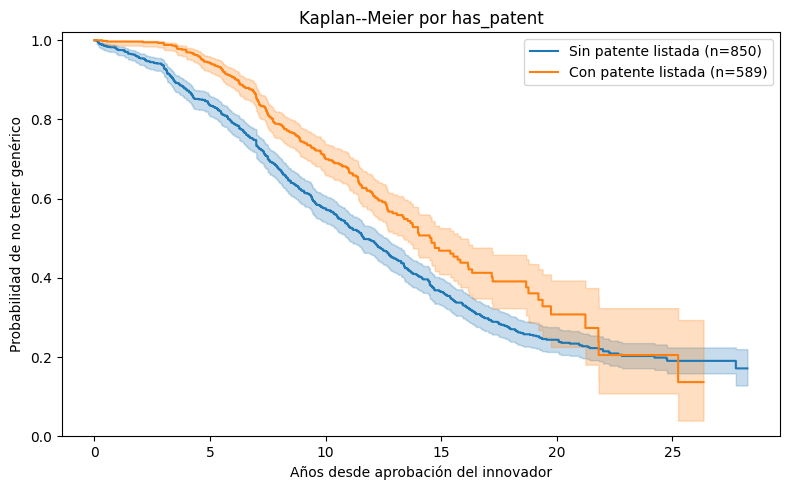

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_patent,850,589,618,241,11.646817,14.576318,23.339173,0.000001


Curvas Kaplan--Meier: has_exclusivity
Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/km_by_has_exclusivity.png


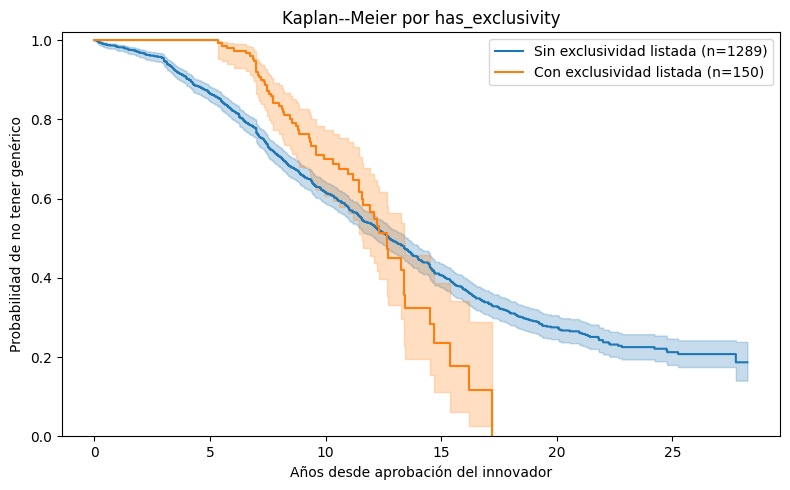

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_exclusivity,1289,150,797,62,12.758385,12.640657,0.887236,0.346227


Curvas Kaplan--Meier: has_drug_substance_patent
Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/km_by_drug_substance_patent.png


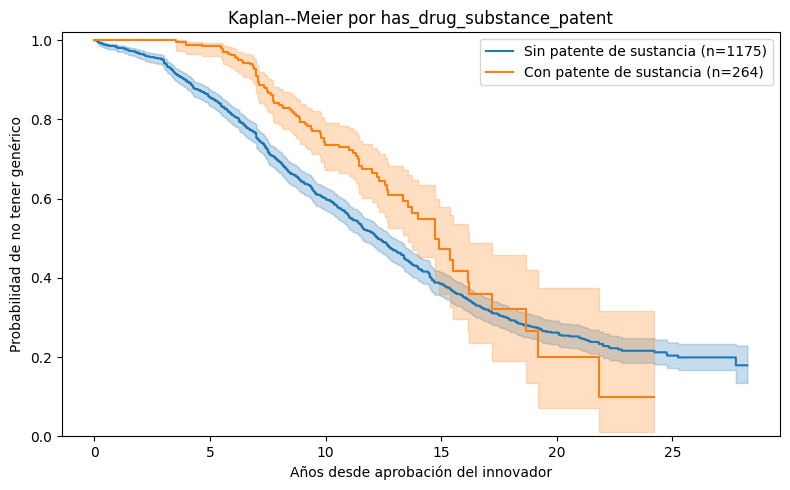

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_drug_substance_patent,1175,264,769,90,12.246407,14.724162,17.293805,0.000032


Curvas Kaplan--Meier: has_drug_product_patent
Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/km_by_drug_product_patent.png


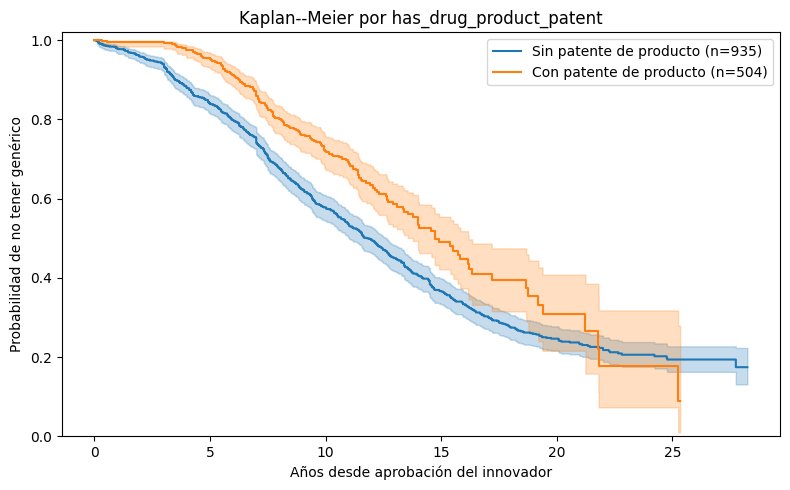

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_drug_product_patent,935,504,667,192,11.78371,14.724162,25.254709,5.023677e-07


Curvas Kaplan--Meier: has_patent_use_code
Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/km_by_patent_use_code.png


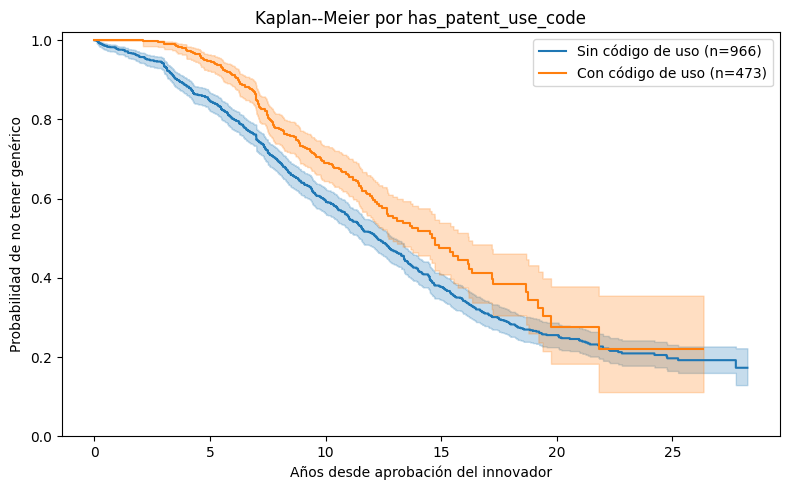

,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_patent_use_code,966,473,667,192,12.246407,14.715948,14.3135,0.000155


Resumen global de comparaciones Kaplan--Meier


,group_col,n_false,n_true,events_false,events_true,km_median_false,km_median_true,logrank_statistic,logrank_p_value
0,has_patent,850,589,618,241,11.646817,14.576318,23.339173,1.358058e-06
1,has_exclusivity,1289,150,797,62,12.758385,12.640657,0.887236,3.462273e-01
2,has_drug_substance_patent,1175,264,769,90,12.246407,14.724162,17.293805,3.202292e-05
3,has_drug_product_patent,935,504,667,192,11.783710,14.724162,25.254709,5.023677e-07
4,has_patent_use_code,966,473,667,192,12.246407,14.715948,14.313500,1.547511e-04


In [16]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

def plot_km_by_binary_group(df, group_col, label_false=None, label_true=None, filename=None):
    """
    Grafica curvas Kaplan--Meier para una variable booleana.
    """
    label_false = label_false or f"{group_col} = False"
    label_true = label_true or f"{group_col} = True"
    
    data_false = df.loc[df[group_col].eq(False)].copy()
    data_true = df.loc[df[group_col].eq(True)].copy()
    
    kmf_false = KaplanMeierFitter()
    kmf_true = KaplanMeierFitter()
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    kmf_false.fit(
        durations=data_false["time_to_generic_years"],
        event_observed=data_false["event"],
        label=f"{label_false} (n={len(data_false)})"
    )
    kmf_false.plot_survival_function(ax=ax, ci_show=True)
    
    kmf_true.fit(
        durations=data_true["time_to_generic_years"],
        event_observed=data_true["event"],
        label=f"{label_true} (n={len(data_true)})"
    )
    kmf_true.plot_survival_function(ax=ax, ci_show=True)
    
    ax.set_xlabel("Años desde aprobación del innovador")
    ax.set_ylabel("Probabilidad de no tener genérico")
    ax.set_title(f"Kaplan--Meier por {group_col}")
    ax.set_ylim(0, 1.02)
    
    plt.tight_layout()
    
    if filename is not None:
        fig_path = FIGURES_DIR / filename
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Figura guardada en: {fig_path}")
    
    plt.show()
    
    # Log-rank test
    result = logrank_test(
        data_false["time_to_generic_years"],
        data_true["time_to_generic_years"],
        event_observed_A=data_false["event"],
        event_observed_B=data_true["event"]
    )
    
    summary = pd.DataFrame({
        "group_col": [group_col],
        "n_false": [len(data_false)],
        "n_true": [len(data_true)],
        "events_false": [data_false["event"].sum()],
        "events_true": [data_true["event"].sum()],
        "km_median_false": [kmf_false.median_survival_time_],
        "km_median_true": [kmf_true.median_survival_time_],
        "logrank_statistic": [result.test_statistic],
        "logrank_p_value": [result.p_value]
    })
    
    return summary


km_group_summaries = []

comparisons = [
    ("has_patent", "Sin patente listada", "Con patente listada", "km_by_has_patent.png"),
    ("has_exclusivity", "Sin exclusividad listada", "Con exclusividad listada", "km_by_has_exclusivity.png"),
    ("has_drug_substance_patent", "Sin patente de sustancia", "Con patente de sustancia", "km_by_drug_substance_patent.png"),
    ("has_drug_product_patent", "Sin patente de producto", "Con patente de producto", "km_by_drug_product_patent.png"),
    ("has_patent_use_code", "Sin código de uso", "Con código de uso", "km_by_patent_use_code.png"),
]

for group_col, label_false, label_true, filename in comparisons:
    print("=" * 80)
    print(f"Curvas Kaplan--Meier: {group_col}")
    print("=" * 80)
    
    summary = plot_km_by_binary_group(
        survival_v2,
        group_col=group_col,
        label_false=label_false,
        label_true=label_true,
        filename=filename
    )
    
    display(summary)
    km_group_summaries.append(summary)

km_group_summary_table = pd.concat(km_group_summaries, ignore_index=True)

print("=" * 80)
print("Resumen global de comparaciones Kaplan--Meier")
print("=" * 80)
display(km_group_summary_table)

Las curvas Kaplan--Meier por subgrupos se generaron correctamente y muestran diferencias relevantes entre unidades con y sin ciertas características regulatorias.

En la comparación general **con patente listada vs sin patente listada**, la curva del grupo con patente se mantiene por encima de la curva del grupo sin patente durante buena parte del seguimiento. Esto significa que las unidades con patente tienden a permanecer más tiempo sin genérico observado. La mediana Kaplan--Meier fue aproximadamente:

- sin patente: 11.65 años;
- con patente: 14.58 años.

La prueba log-rank fue significativa, con $p \approx 1.36 \times 10^{-6}$, lo que sugiere diferencias globales entre ambas curvas.

Un patrón similar aparece para las patentes de sustancia, patentes de producto y códigos de uso de patente:

- con patente de sustancia: mediana KM ≈ 14.72 años;
- con patente de producto: mediana KM ≈ 14.72 años;
- con código de uso: mediana KM ≈ 14.72 años.

En los tres casos, las pruebas log-rank fueron significativas. Esto sugiere que las unidades con estos tipos de protección tienden a tener tiempos más largos hasta la entrada de genéricos.

En cambio, la comparación **con exclusividad listada vs sin exclusividad listada** no mostró una diferencia estadísticamente clara en la prueba log-rank. La mediana KM fue muy similar:

- sin exclusividad: 12.76 años;
- con exclusividad: 12.64 años.

El valor $p \approx 0.346$ indica que, bajo esta comparación exploratoria, no se detecta una diferencia global fuerte entre ambas curvas.

Estos resultados deben interpretarse con cautela. Aunque Kaplan--Meier maneja adecuadamente la censura, las comparaciones no ajustan por posibles factores de confusión, como año de aprobación, ruta de administración, forma farmacéutica, tipo de producto o clase terapéutica. Además, las patentes y exclusividades provienen de la versión actual del Orange Book, por lo que no necesariamente representan todo el historial regulatorio desde la fecha de aprobación original.

Aun así, estos resultados son útiles como primera evidencia exploratoria: la presencia de patentes, especialmente de sustancia, producto o uso, parece estar asociada con una entrada más tardía de genéricos.

## 8. Guardado de la base enriquecida y tablas de resumen

Después de integrar patentes y exclusividades y generar las primeras comparaciones Kaplan--Meier por subgrupos, guardaremos los principales resultados de este notebook.

Se guardarán tres salidas:

1. La base enriquecida `survival_v2`, que contiene el endpoint de supervivencia junto con variables de patentes y exclusividades.
2. La tabla `integration_summary`, que resume la presencia de variables regulatorias en la cohorte.
3. La tabla `km_group_summary_table`, que resume las comparaciones Kaplan--Meier por subgrupos.

Estos archivos permitirán continuar en el siguiente notebook con modelos Cox o AFT sin tener que repetir toda la ingesta y agregación regulatoria.

In [17]:
# Rutas de salida
survival_v2_parquet_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v2_patents_exclusivities.parquet"
survival_v2_csv_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v2_patents_exclusivities.csv"

integration_summary_path = TABLES_DIR / "integration_summary_patents_exclusivities.csv"
km_group_summary_path = TABLES_DIR / "km_group_summary_patents_exclusivities.csv"

# Guardar base enriquecida
survival_v2.to_parquet(survival_v2_parquet_path, index=False)
survival_v2.to_csv(survival_v2_csv_path, index=False)

# Guardar tablas resumen
integration_summary.to_csv(integration_summary_path, index=False)
km_group_summary_table.to_csv(km_group_summary_path, index=False)

print("=" * 80)
print("Archivos guardados correctamente")
print("=" * 80)

print("Base enriquecida:")
print(f"Parquet: {survival_v2_parquet_path}")
print(f"CSV:     {survival_v2_csv_path}")

print("\nTablas resumen:")
print(f"Integración regulatoria: {integration_summary_path}")
print(f"Comparaciones KM:        {km_group_summary_path}")

print("\nDimensiones de survival_v2:")
print(f"Filas: {survival_v2.shape[0]:,}")
print(f"Columnas: {survival_v2.shape[1]:,}")

Archivos guardados correctamente
Base enriquecida:
Parquet: /Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_analysis_v2_patents_exclusivities.parquet
CSV:     /Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_analysis_v2_patents_exclusivities.csv

Tablas resumen:
Integración regulatoria: /Users/juanalbertomartinez/Desktop/Patente/tables/integration_summary_patents_exclusivities.csv
Comparaciones KM:        /Users/juanalbertomartinez/Desktop/Patente/tables/km_group_summary_patents_exclusivities.csv

Dimensiones de survival_v2:
Filas: 1,439
Columnas: 46


Se generaron dos versiones de la base principal:

- `survival_analysis_v2_patents_exclusivities.parquet`
- `survival_analysis_v2_patents_exclusivities.csv`

La versión en `parquet` será la principal para continuar el análisis en Python, mientras que la versión `csv` permitirá revisar los datos de forma manual o compartirlos fácilmente.

También se guardaron dos tablas resumen:

- `integration_summary_patents_exclusivities.csv`, con la frecuencia de variables regulatorias como presencia de patentes, exclusividades, patentes de sustancia, patentes de producto y códigos de uso.
- `km_group_summary_patents_exclusivities.csv`, con las medianas Kaplan--Meier y pruebas log-rank para las comparaciones por subgrupos.

La base final de este notebook conserva:

- 1,439 unidades ingrediente--forma--ruta;
- 46 columnas;
- endpoint de supervivencia;
- variables de patentes;
- variables de exclusividades;
- variables temporales derivadas.

Con esto queda completada la segunda fase del proyecto: integración regulatoria y comparación preliminar mediante curvas Kaplan--Meier.